# **Data Preprocessing**

In [98]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

Data Loading

In [99]:
df = pd.read_excel('premiums.xlsx')

In [100]:
df.shape

(50000, 13)

In [101]:
df.head(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [102]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [103]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [104]:
df.columns = df.columns.str.replace(" ","_").str.lower()

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    50000 non-null  int64 
 1   gender                 50000 non-null  object
 2   region                 50000 non-null  object
 3   marital_status         50000 non-null  object
 4   number_of_dependants   50000 non-null  int64 
 5   bmi_category           50000 non-null  object
 6   smoking_status         49989 non-null  object
 7   employment_status      49998 non-null  object
 8   income_level           49987 non-null  object
 9   income_lakhs           50000 non-null  int64 
 10  medical_history        50000 non-null  object
 11  insurance_plan         50000 non-null  object
 12  annual_premium_amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


In [106]:
df.isna().mean()*100

age                      0.000
gender                   0.000
region                   0.000
marital_status           0.000
number_of_dependants     0.000
bmi_category             0.000
smoking_status           0.022
employment_status        0.004
income_level             0.026
income_lakhs             0.000
medical_history          0.000
insurance_plan           0.000
annual_premium_amount    0.000
dtype: float64

In [107]:
df['income_level'].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L', nan], dtype=object)

In [108]:
df[df['income_level'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
997,20,Female,Southeast,Unmarried,0,Normal,No Smoking,Self-Employed,NaN,5,No Disease,Bronze,7191
7094,33,Male,Southeast,Married,2,Normal,Regular,Self-Employed,NaN,7,High blood pressure,Silver,18335
15395,27,Female,Northeast,Unmarried,2,Underweight,No Smoking,Freelancer,NaN,5,No Disease,Silver,14469
15452,52,Male,Northeast,Married,3,Underweight,No Smoking,Freelancer,NaN,8,Thyroid,Silver,19535
17438,40,Female,Northeast,Married,4,Obesity,Regular,Self-Employed,NaN,8,High blood pressure,Silver,22392
18943,23,Female,Southwest,Unmarried,1,Underweight,No Smoking,NaN,NaN,8,No Disease,Bronze,5873
22553,37,Female,Southeast,Unmarried,0,Underweight,Regular,Salaried,NaN,7,High blood pressure,Silver,18631
24317,18,Male,Southwest,Married,3,Normal,Occasional,Freelancer,NaN,6,No Disease,Silver,8484
30421,39,Female,Southeast,Unmarried,2,Obesity,No Smoking,NaN,NaN,8,High blood pressure,Silver,20114
37325,19,Male,Southeast,Unmarried,0,Overweight,Occasional,Salaried,NaN,3,No Disease,Silver,9174


In [109]:
df['employment_status'].unique()

array(['Salaried', 'Self-Employed', 'Freelancer', nan], dtype=object)

In [110]:
df['medical_history'].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [111]:
df[df['smoking_status'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
177,26,Female,Southwest,Married,3,Underweight,NaN,Salaried,> 40L,69,Diabetes,Gold,22605
15648,47,Male,Southwest,Married,4,Normal,NaN,Freelancer,25L - 40L,32,Diabetes,Gold,26100
16324,45,Male,Northwest,Married,4,Overweight,NaN,Salaried,10L - 25L,16,High blood pressure & Heart disease,Silver,21881
16941,34,Male,Southwest,Married,5,Normal,NaN,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Gold,25865
16975,23,Male,Southwest,Unmarried,0,Normal,NaN,Freelancer,<10L,3,No Disease,Bronze,6001
18005,61,Female,Southwest,Married,2,Normal,NaN,Self-Employed,25L - 40L,27,Thyroid,Gold,32501
19218,19,Female,Northeast,Unmarried,0,Normal,NaN,Salaried,10L - 25L,23,No Disease,Bronze,9010
20335,50,Female,Northeast,Married,3,Underweight,NaN,Salaried,25L - 40L,25,High blood pressure,Gold,27317
22833,69,Male,Southeast,Married,2,Normal,NaN,Freelancer,<10L,9,Diabetes,Silver,23118
25519,54,Male,Southwest,Married,3,Overweight,NaN,Salaried,> 40L,54,High blood pressure & Heart disease,Silver,24907


In [112]:
df[(df['medical_history'] == 'High blood pressure & Heart disease') & (df['bmi_category'] == 'Overweight')]['smoking_status'].mode()

0    Regular
Name: smoking_status, dtype: object

In [113]:
smoking_mode = (
    df.groupby(['medical_history', 'bmi_category'])['smoking_status']
    .agg(lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else None)
    .reset_index()
)

print(smoking_mode)

                        medical_history bmi_category smoking_status
0                              Diabetes       Normal     No Smoking
1                              Diabetes      Obesity     No Smoking
2                              Diabetes   Overweight     No Smoking
3                              Diabetes  Underweight     No Smoking
4              Diabetes & Heart disease       Normal     No Smoking
5              Diabetes & Heart disease      Obesity     No Smoking
6              Diabetes & Heart disease   Overweight        Regular
7              Diabetes & Heart disease  Underweight     No Smoking
8        Diabetes & High blood pressure       Normal     No Smoking
9        Diabetes & High blood pressure      Obesity     No Smoking
10       Diabetes & High blood pressure   Overweight     No Smoking
11       Diabetes & High blood pressure  Underweight     No Smoking
12                   Diabetes & Thyroid       Normal     No Smoking
13                   Diabetes & Thyroid      Obe

In [114]:
"""
Handling Missing Values:

- income_level:
  Missingness is likely dependent on the observed feature income_lakhs,
  as both represent income information. Hence, this is classified as MAR
  (Missing At Random). I impute income_level using income_lakhs.

- smoking_status:
  Missingness is likely related to the unobserved value itself, as individuals
  may choose not to disclose their smoking habits. Therefore, it is classified
  as MNAR (Missing Not At Random). Instead of naive imputation, I treat missing
  values as a separate category ('Unknown') and optionally create a missing indicator.

- employment_status:
  Missingness does not appear to depend on the value itself but may depend on
  other observed features such as income_level. Hence, it is treated as MAR.
  I impute missing values using conditional mode imputation based on income_level.
"""


"\nHandling Missing Values:\n\n- income_level:\n  Missingness is likely dependent on the observed feature income_lakhs,\n  as both represent income information. Hence, this is classified as MAR\n  (Missing At Random). I impute income_level using income_lakhs.\n\n- smoking_status:\n  Missingness is likely related to the unobserved value itself, as individuals\n  may choose not to disclose their smoking habits. Therefore, it is classified\n  as MNAR (Missing Not At Random). Instead of naive imputation, I treat missing\n  values as a separate category ('Unknown') and optionally create a missing indicator.\n\n- employment_status:\n  Missingness does not appear to depend on the value itself but may depend on\n  other observed features such as income_level. Hence, it is treated as MAR.\n  I impute missing values using conditional mode imputation based on income_level.\n"

In [115]:
def map_income_level(x):
    if pd.isna(x):
        return None
    elif x < 10:
        return '<10L'
    elif 10 <= x < 25:
        return '10L - 25L'
    elif 25 <= x < 40:
        return '25L - 40L'
    else:
        return '> 40L'

In [116]:
mask = df['income_level'].isna()
df.loc[mask, 'income_level'] = df.loc[mask, 'income_lakhs'].apply(map_income_level)

In [117]:
df['smoking_status'] = df['smoking_status'].fillna('Unknown')

In [118]:
global_mode = df['employment_status'].mode()[0]

def fill_mode_safe(series):
    mode = series.mode()
    return series.fillna(mode[0] if not mode.empty else global_mode)

df['employment_status'] = (
    df.groupby('income_level')['employment_status']
      .transform(fill_mode_safe)
)

In [119]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [120]:
df['number_of_dependants'].value_counts()/len(df)*100

number_of_dependants
 0    30.868
 3    22.026
 1    17.354
 2    16.846
 4     9.454
 5     3.308
-1     0.080
-3     0.064
Name: count, dtype: float64

In [121]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

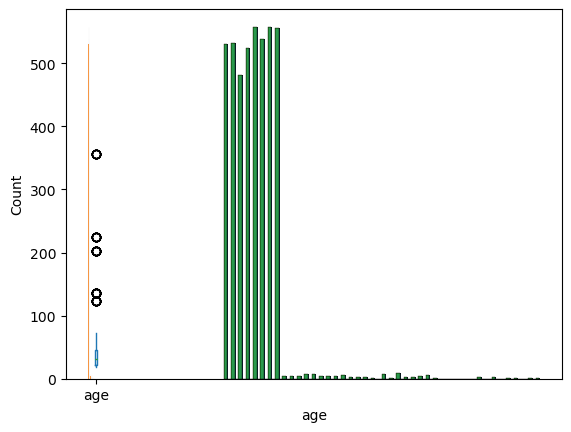

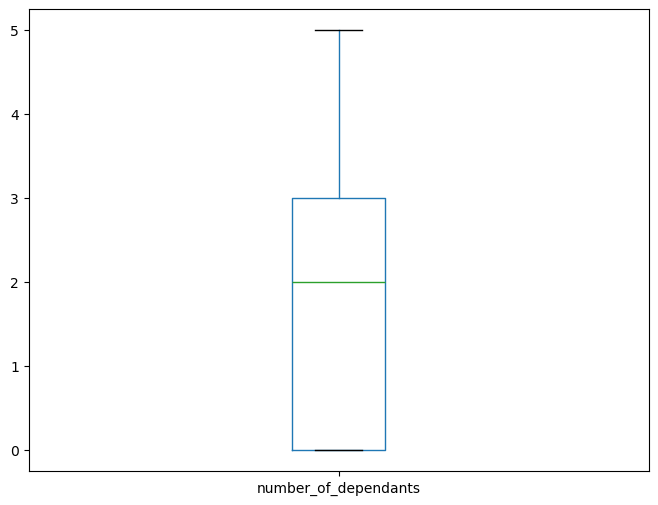

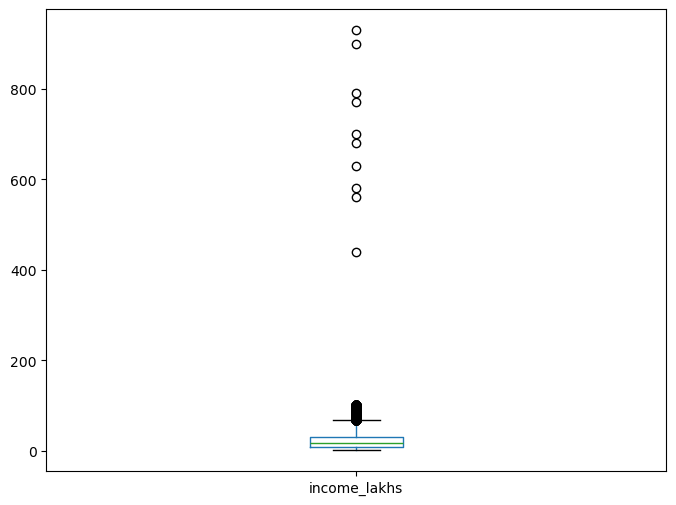

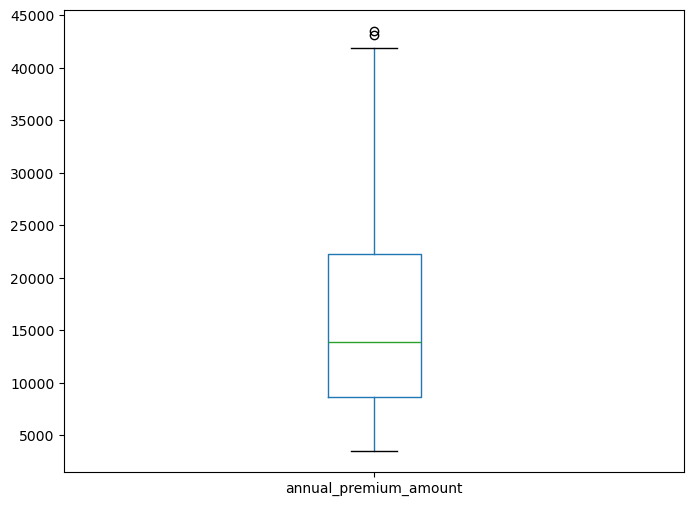

In [122]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
  df.boxplot(column=col, grid=False, figsize=(8, 6))
  plt.show()

In [123]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers_iqr(df, 'age')

In [124]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49942.000000,49942.000000,49942.000000,49942.000000
mean,34.403648,1.717853,23.022186,15767.897041
std,13.682354,1.492130,24.225309,8418.981981
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.000000
max,72.000000,5.000000,930.000000,43471.000000


In [125]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
  print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status:['No Smoking' 'Regular' 'Occasional' 'Unknown' 'Smoking=0'
 'Does Not Smoke' 'Not Smoking']
employment_status:['Salaried' 'Self-Employed' 'Freelancer']
income_level:['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history:['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan:['Bronze' 'Silver' 'Gold']


In [126]:
df.duplicated().sum()

0

In [127]:
df['smoking_status'] = df['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})

df['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional', 'Unknown'], dtype=object)

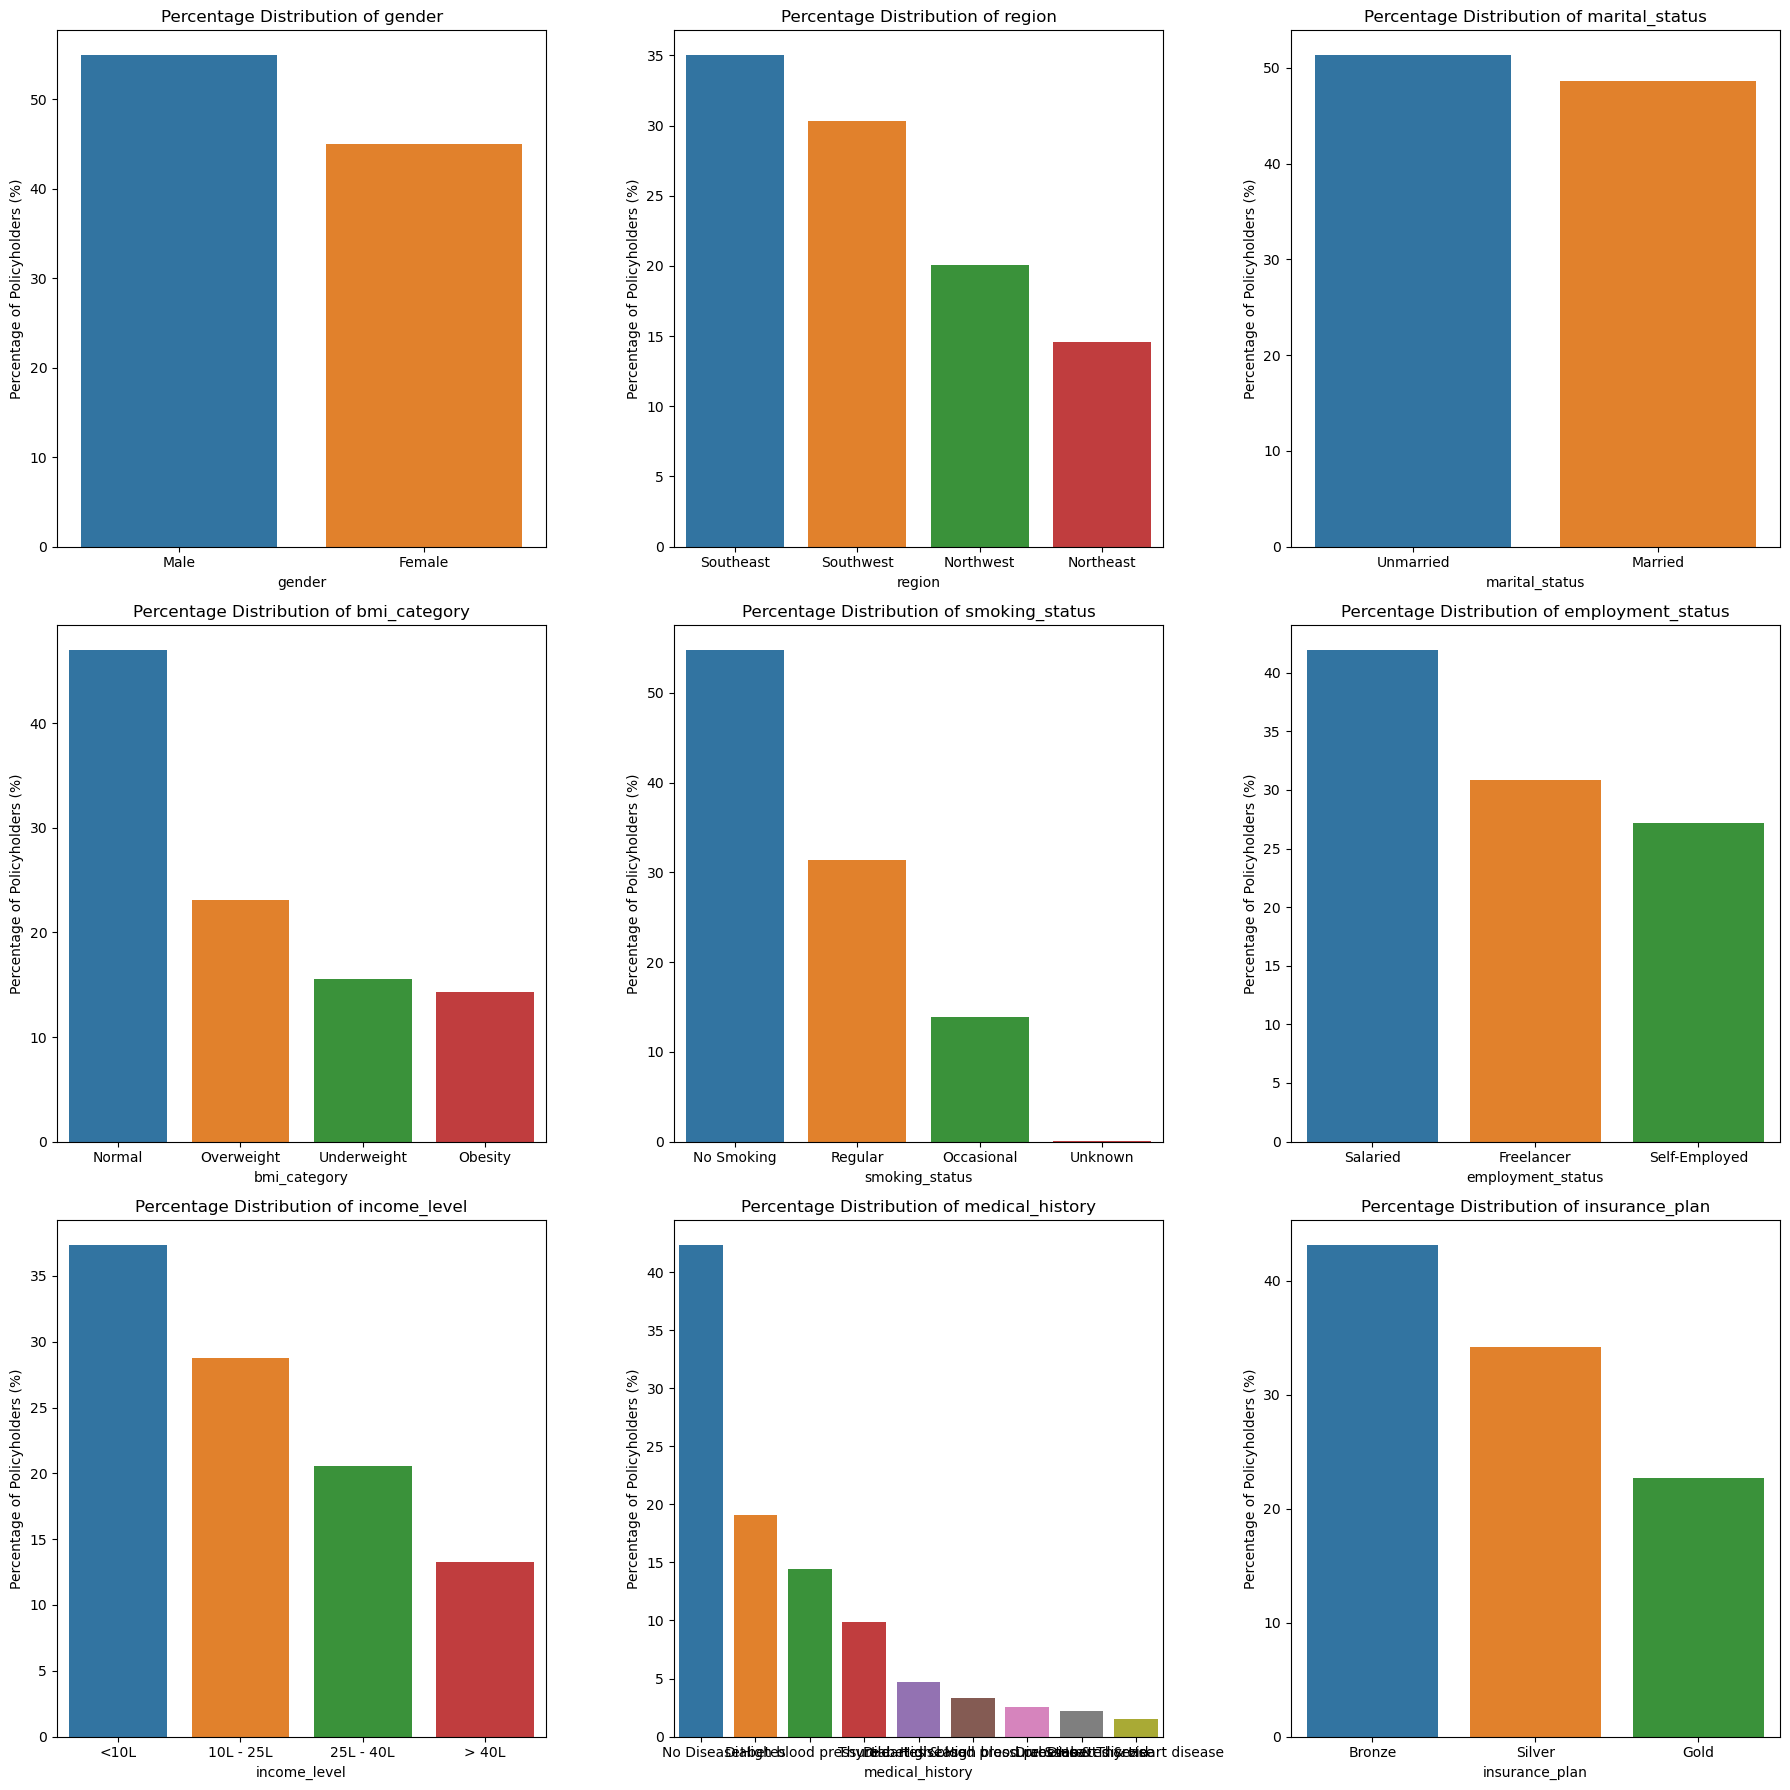

In [128]:
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies

    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

In [129]:
crosstab = pd.crosstab(df['income_level'], df['insurance_plan'])
print(crosstab)

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         5308  3880    5183
25L - 40L         3683  2845    3750
<10L             12229   931    5498
> 40L              330  3659    2646


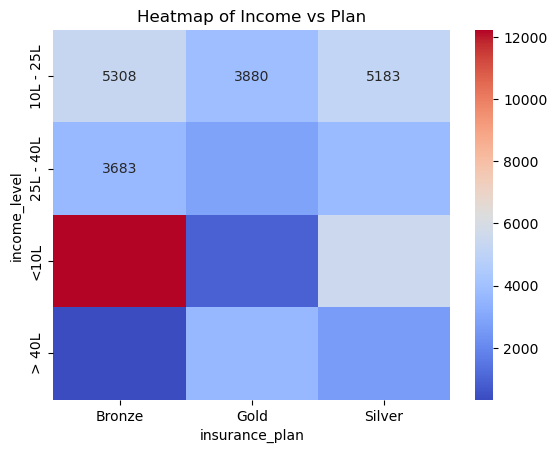

In [130]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Income vs Plan')
plt.show()

In [131]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df[['disease1', 'disease2']] = df['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df['disease1'] = df['disease1'].fillna('none')
df['disease2'] = df['disease2'].fillna('none')
df['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df['total_risk_score'] += df[disease].map(risk_scores)

# Normalize the risk score to a range of 0 to 1
max_score = df['total_risk_score'].max()
min_score = df['total_risk_score'].min()
df['normalized_risk_score'] = (df['total_risk_score'] - min_score) / (max_score - min_score)
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571


In [132]:
df['insurance_plan'] = df['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [133]:
df['income_level'] = df['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [134]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,1,0,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,0,0,1,0,0,0,1,0,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1


In [135]:
df = df.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,0,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,0,1


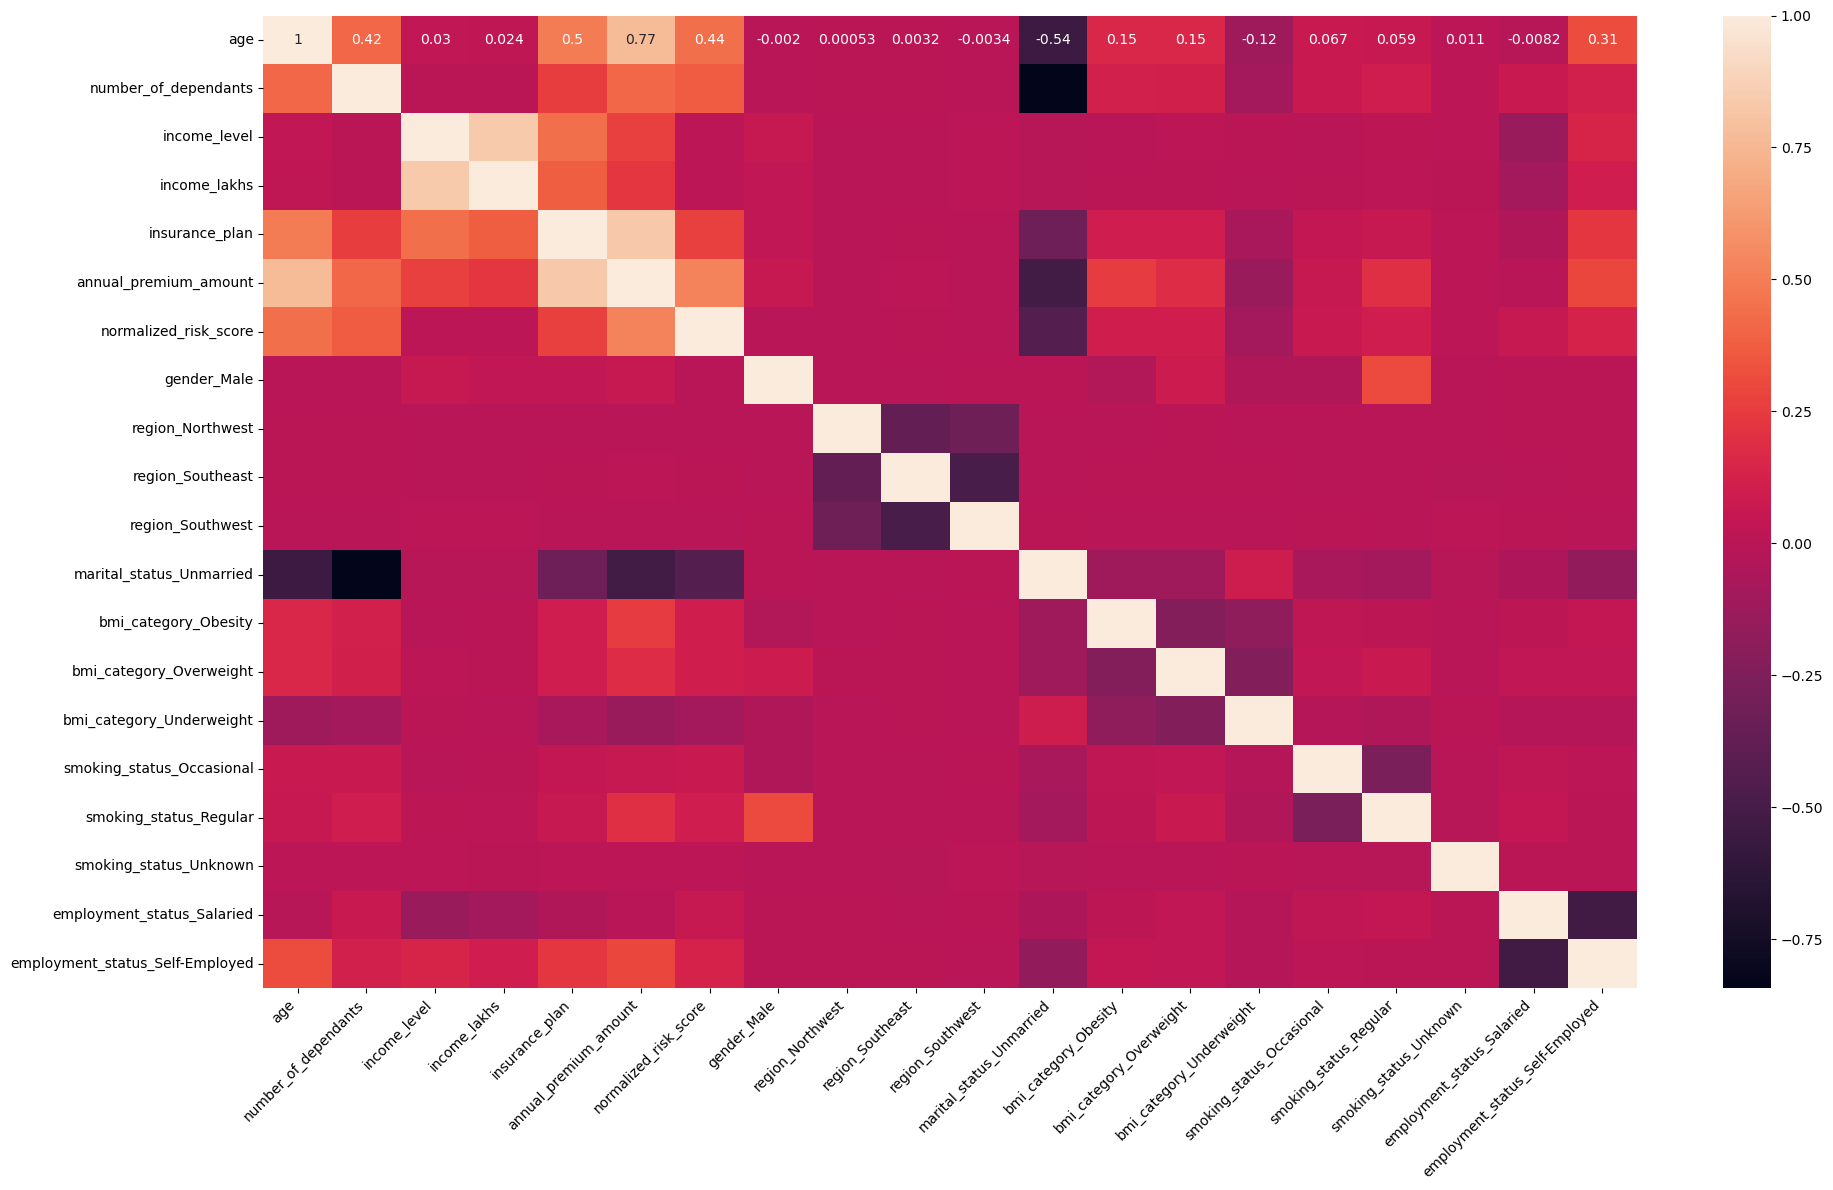

In [136]:
cm = df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [137]:
X = df.drop('annual_premium_amount', axis='columns')
y = df['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
count,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.000000,49942.00000,49942.000000,49942.000000,49942.00000,49942.000000,49942.000000
mean,0.303771,0.343571,0.365971,0.023705,0.397531,0.291857,0.549578,0.200873,0.350326,0.303112,0.513476,0.143246,0.231168,0.15538,0.138300,0.313724,0.00022,0.419427,0.272036
std,0.253377,0.298426,0.349801,0.026077,0.392453,0.287428,0.497541,0.400657,0.477077,0.459608,0.499823,0.350327,0.421584,0.36227,0.345218,0.464010,0.01484,0.493470,0.445013
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.006459,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.017223,0.500000,0.357143,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.032293,0.500000,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000


In [138]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [139]:
calculate_vif(X)

,Column,VIF
0,age,4.568084
1,number_of_dependants,4.533925
2,income_level,7.762381
3,income_lakhs,6.213498
4,insurance_plan,3.583652
5,normalized_risk_score,2.688349
6,gender_Male,2.419668
7,region_Northwest,2.101995
8,region_Southeast,2.921384
9,region_Southwest,2.670459


In [140]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,4.528933
1,number_of_dependants,4.514961
2,income_lakhs,2.210420
3,insurance_plan,3.319450
4,normalized_risk_score,2.688079
5,gender_Male,2.408380
6,region_Northwest,2.099136
7,region_Southeast,2.916707
8,region_Southwest,2.665663
9,marital_status_Unmarried,3.369984


In [141]:
# # we will drop income_lakhs due to high VIF value
# X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:blue">Model Training</h2>

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (34959, 19)
x test:  (14983, 19)
y train:  (34959,)
y test:  (14983,)


In [143]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9286436173293995, 0.9274984917876399)

In [144]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  5146993.252686437 RMSE:  2268.6985812765956


In [145]:
X_test.shape

(14983, 19)

In [146]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([11326.41958 ,  -565.857241,   500.420765, -7651.026341,
       12391.651761,  4769.597165,   127.611385,   -41.242739,
          46.16642 ,   -16.278696,  -870.134324,  3338.421711,
        1614.35669 ,   336.1065  ,   694.290155,  2216.008436,
         427.101042,   175.372078,   378.535701])

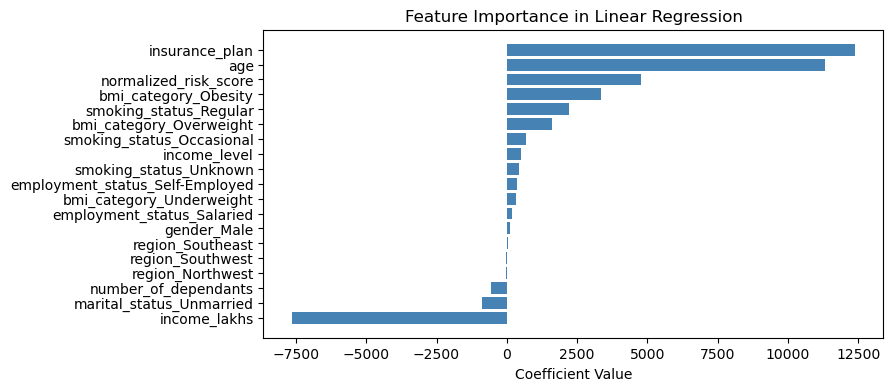

In [147]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [148]:
# Ridge Regression Model
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.928641185081118, 0.9274837315722414)

In [149]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  5148041.103013098 RMSE:  2268.9295059593846


In [150]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9782891590973135

In [151]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  1541285.8903427024 RMSE:  1241.48535647534


In [152]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=None)
random_search.fit(X_train, y_train)
random_search.best_score_

0.9807735971131306

In [153]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [154]:
best_model = random_search.best_estimator_

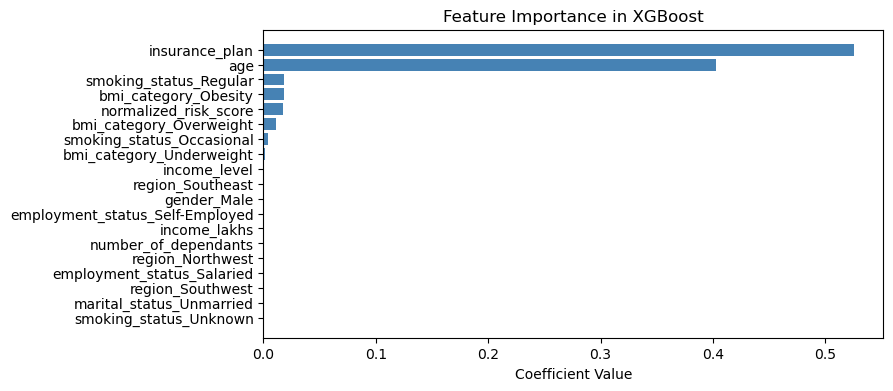

In [155]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [156]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
7165,11689,11285.062500,-403.937500,-3.455706
32445,32892,32514.681641,-377.318359,-1.147143
34491,7108,8157.349121,1049.349121,14.762931
47909,26011,25169.830078,-841.169922,-3.233901
12855,28647,28441.187500,-205.812500,-0.718443


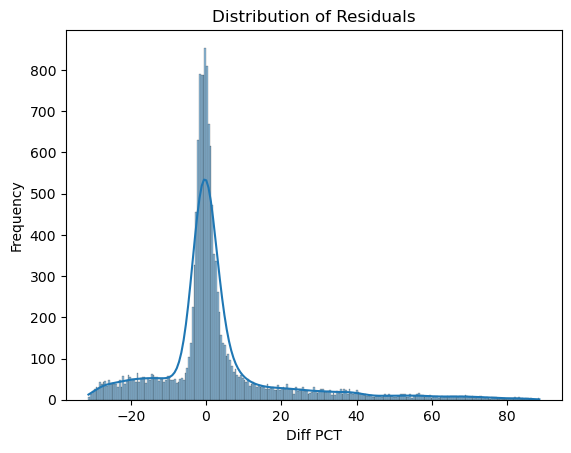

In [157]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [158]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
34491,7108,8157.349121,1049.349121,14.762931
33888,8079,10788.488281,2709.488281,33.537421
46928,3946,6591.620117,2645.620117,67.045619
25512,8491,10813.865234,2322.865234,27.356792
9389,8345,10813.686523,2468.686523,29.582822


In [159]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

29.219782420076086

In [160]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
36269,3501,6601.687500,3100.687500,88.565767
29904,3503,6601.687500,3098.687500,88.458107
46118,3508,6601.687500,3093.687500,88.189495
37192,3541,6601.687500,3060.687500,86.435682
41227,3538,6591.620117,3053.620117,86.309218
...,...,...,...,...
43357,4439,6668.172852,2229.172852,50.217906
16960,4752,7135.741211,2383.741211,50.162904
8463,4874,7318.252441,2444.252441,50.148799
29083,4866,7302.531738,2436.531738,50.072580


In [161]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
34491,0.222222,0.8,0.0,0.000000,0.0,0.0,1,0,1,0,0,0,0,1,0,0,0,1,0
33888,0.074074,0.2,1.0,0.054898,0.5,0.0,0,1,0,0,1,0,0,0,0,1,0,0,0


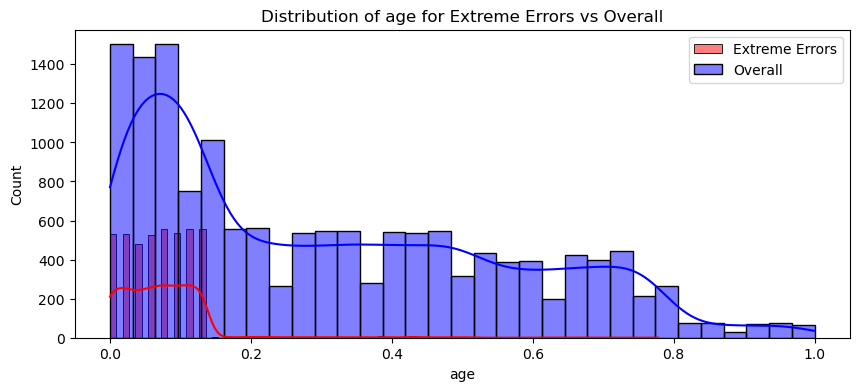

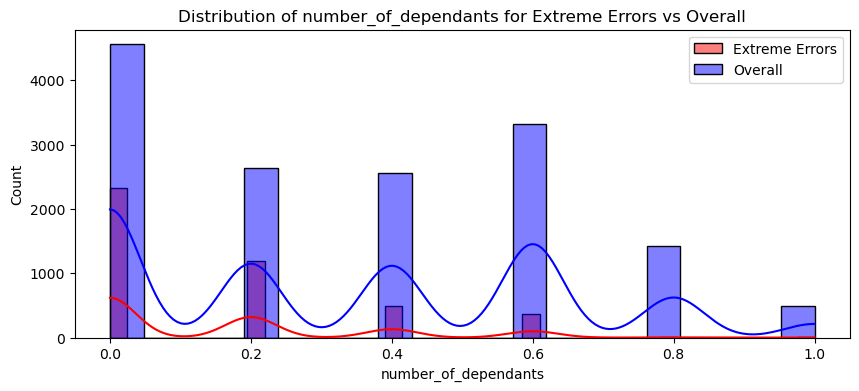

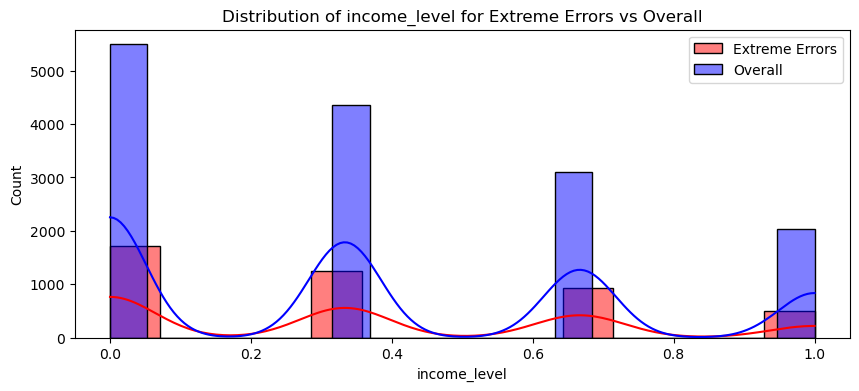

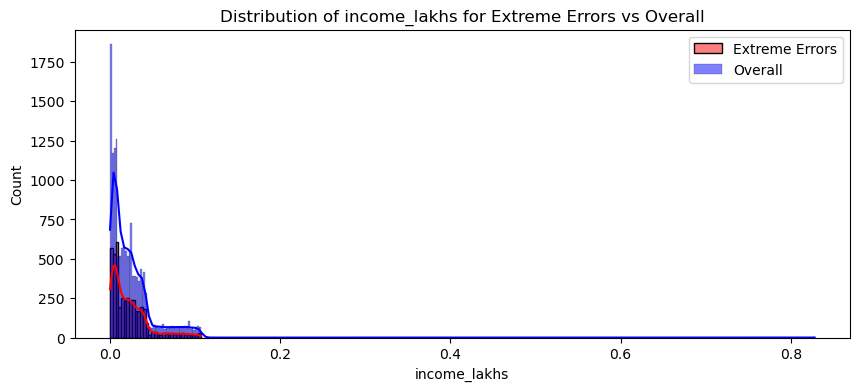

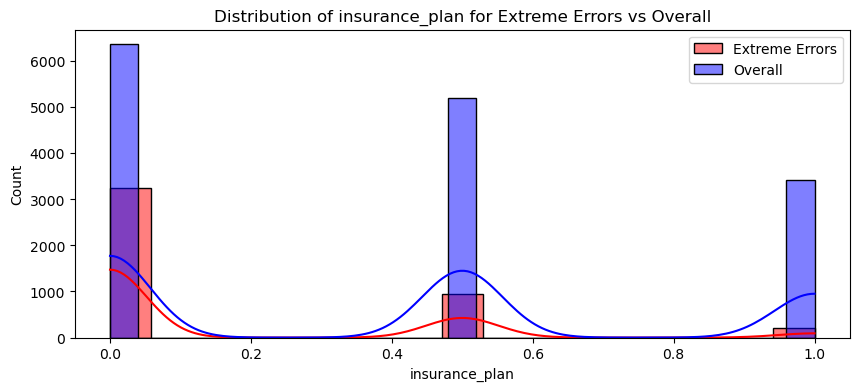

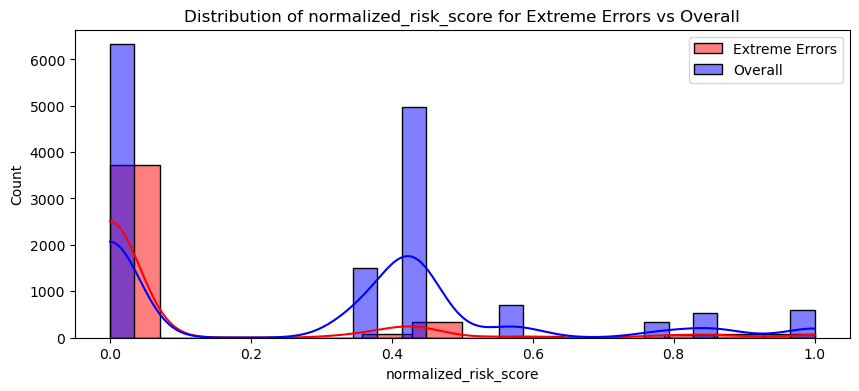

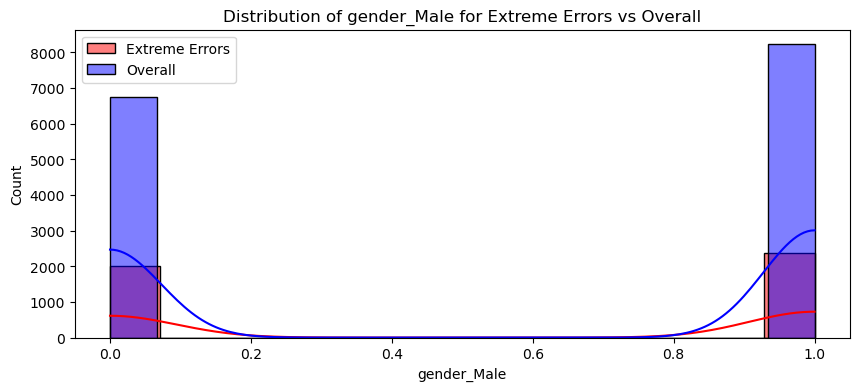

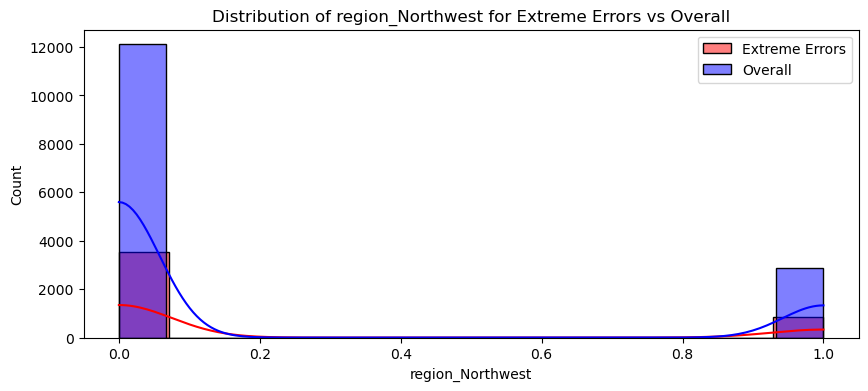

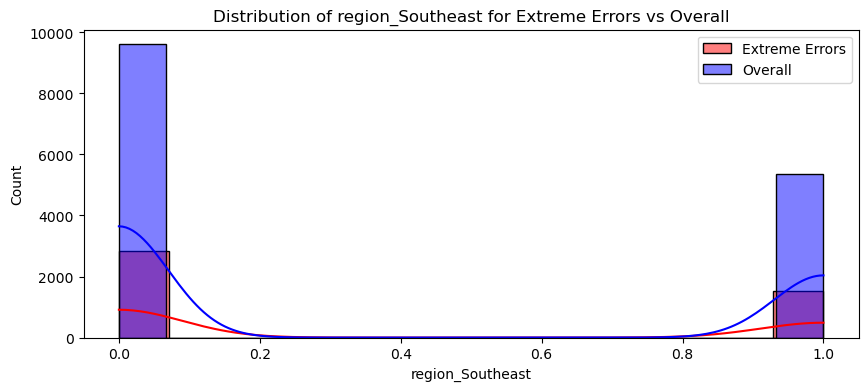

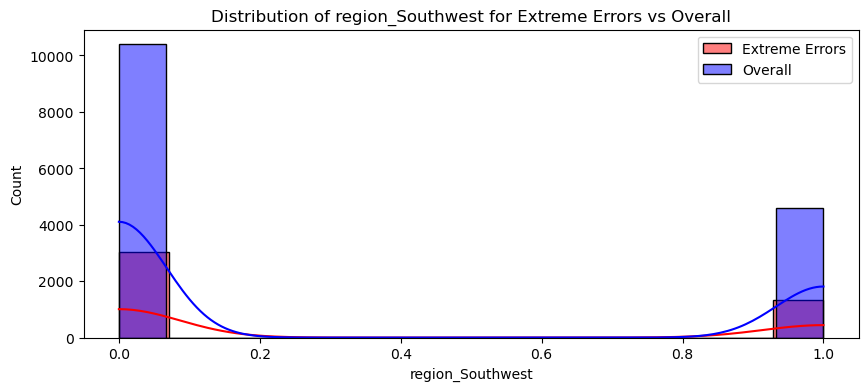

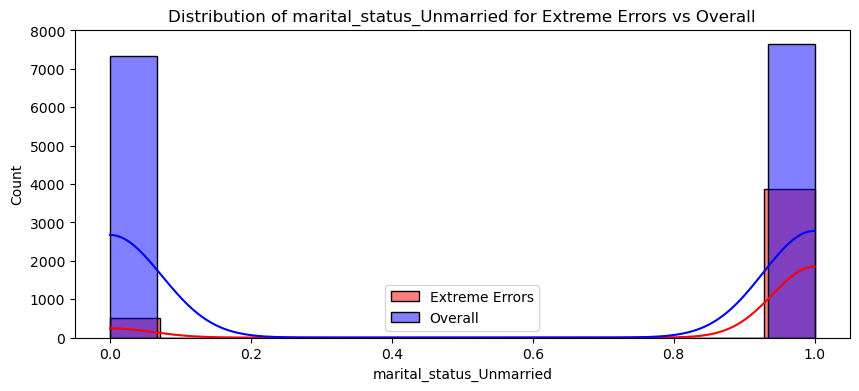

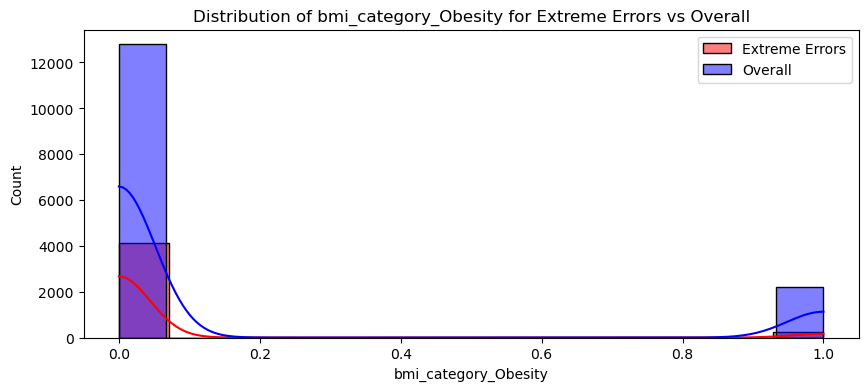

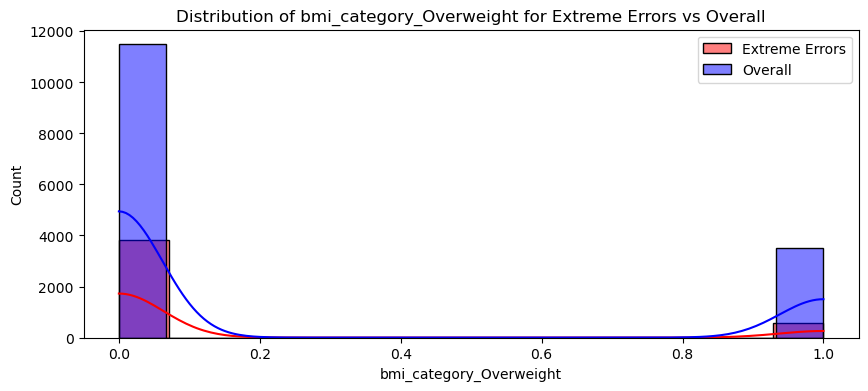

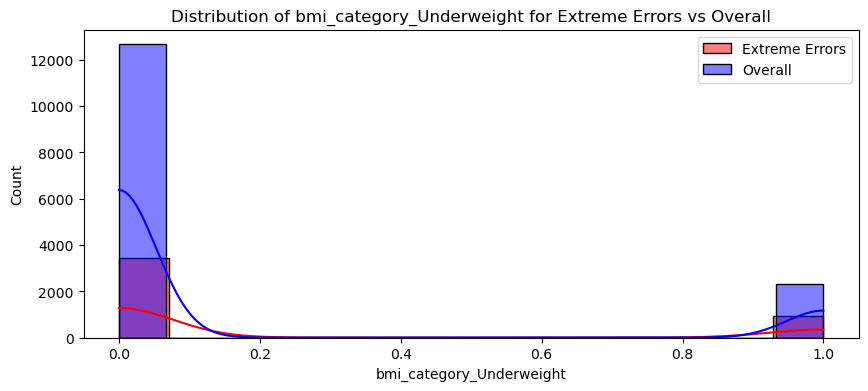

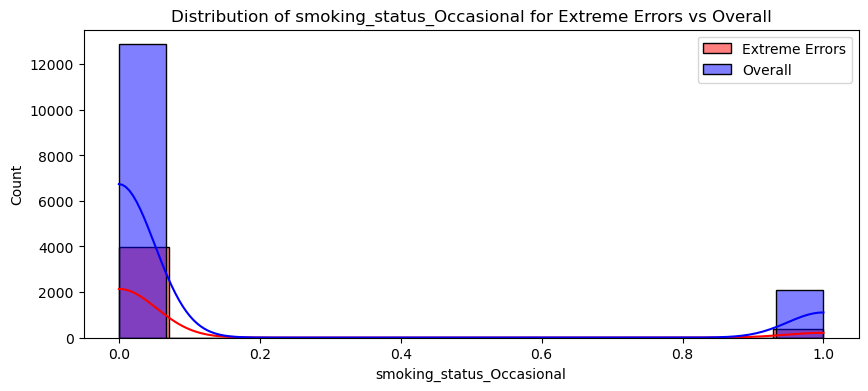

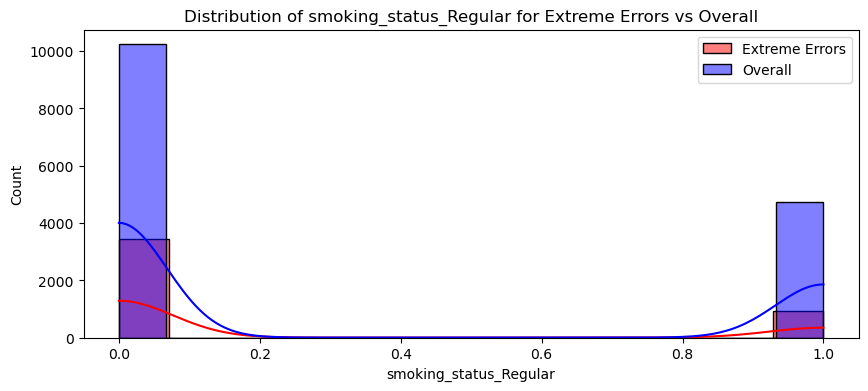

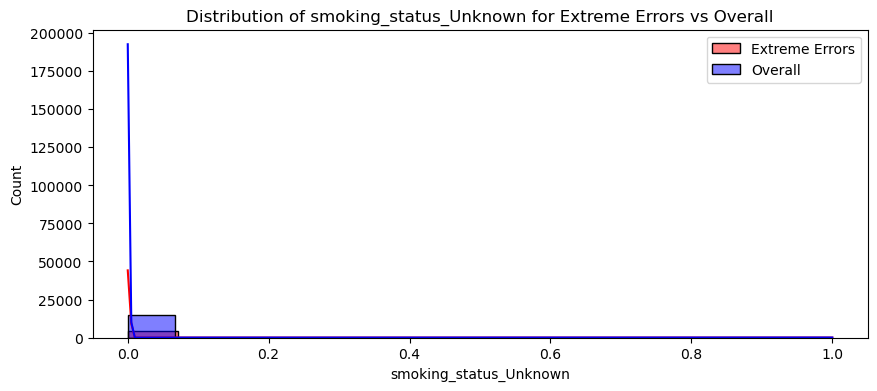

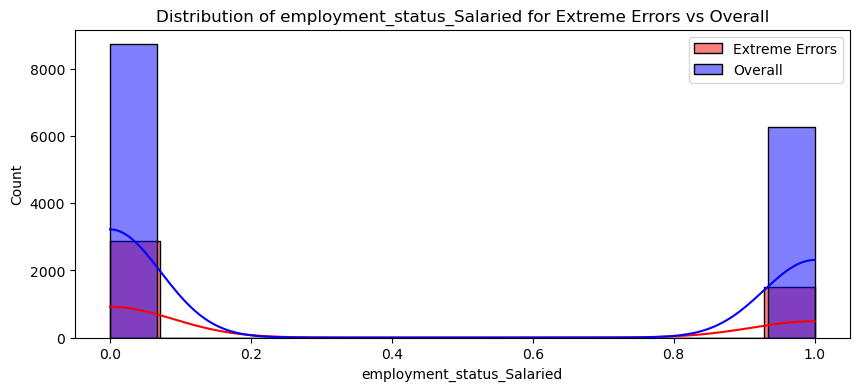

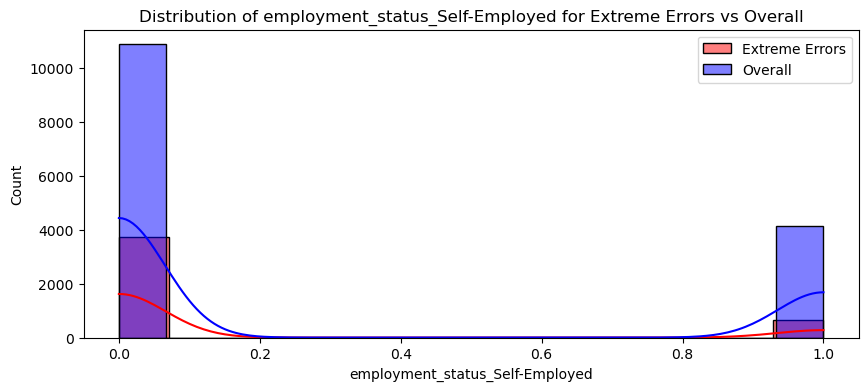

In [162]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [163]:
# extreme_errors_df['income_level']=-1

In [164]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,30.0,4.0,1.0,1.0,1.0
1,22.0,1.0,4.0,52.0,2.0
2,22.0,1.0,2.0,18.0,1.0
3,20.0,1.0,4.0,58.0,2.0
4,22.0,3.0,4.0,86.0,2.0


In [165]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,4378.000000,4378.000000,4378.000000,4378.000000,4378.000000
mean,21.903381,0.759251,2.047053,21.631110,1.306076
std,3.433168,0.974691,1.024077,20.692253,0.552035
min,18.000000,0.000000,1.000000,1.000000,1.000000
25%,20.000000,0.000000,1.000000,6.000000,1.000000
50%,22.000000,0.000000,2.000000,16.000000,1.000000
75%,24.000000,1.000000,3.000000,31.000000,2.000000
max,60.000000,5.000000,4.000000,100.000000,3.000000


In [166]:
df_reversed['age']

0       30.0
1       22.0
2       22.0
3       20.0
4       22.0
        ... 
4373    24.0
4374    18.0
4375    24.0
4376    22.0
4377    18.0
Name: age, Length: 4378, dtype: float64

In [167]:
df_reversed['age'].quantile(q=0.97)

25.0

In [169]:
sns.histplot(df_reversed.age)

<Axes: xlabel='age', ylabel='Count'>

This shows that majority of the extreme errors are coming from young age group (i.e. <25 years of age). We need to may be build a separate model for this segment